<a href="https://colab.research.google.com/github/Pushkarsinghs/indian_stock-analysis/blob/main/04_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Indian Stock Market Analysis
## Notebook 4: Sentiment Analysis

This notebook scrapes financial news headlines for NIFTY 50 stocks and scores
market sentiment using NLP — helping identify bullish or bearish market mood.

**Sources:** Google News RSS, Economic Times
**Methods:** TextBlob (polarity scoring), Keyword-based sentiment
**Output:** Sentiment scores per stock + Power BI ready CSV

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install textblob pyarrow feedparser -q
!python -m textblob.download_corpora -q

import pandas as pd
import numpy as np
import feedparser
import requests
from textblob import TextBlob
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

print("✅ Libraries ready!")

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.7 MB/s eta 0:00:00
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.
✅ Libraries ready!


In [2]:
# Company names for news searching
# (ticker → search-friendly company name)
COMPANY_NAMES = {
    "RELIANCE.NS":   "Reliance Industries",
    "TCS.NS":        "TCS Tata Consultancy",
    "HDFCBANK.NS":   "HDFC Bank",
    "INFY.NS":       "Infosys",
    "ICICIBANK.NS":  "ICICI Bank",
    "HINDUNILVR.NS": "Hindustan Unilever HUL",
    "ITC.NS":        "ITC Limited",
    "SBIN.NS":       "State Bank India SBI",
    "BHARTIARTL.NS": "Bharti Airtel",
    "KOTAKBANK.NS":  "Kotak Mahindra Bank",
    "LT.NS":         "Larsen Toubro",
    "AXISBANK.NS":   "Axis Bank",
    "ASIANPAINT.NS": "Asian Paints",
    "MARUTI.NS":     "Maruti Suzuki",
    "SUNPHARMA.NS":  "Sun Pharma",
    "TITAN.NS":      "Titan Company",
    "ULTRACEMCO.NS": "UltraTech Cement",
    "BAJFINANCE.NS": "Bajaj Finance",
    "WIPRO.NS":      "Wipro",
    "ONGC.NS":       "ONGC Oil Gas",
    "NTPC.NS":       "NTPC Power",
    "POWERGRID.NS":  "Power Grid India",
    "TECHM.NS":      "Tech Mahindra",
    "HCLTECH.NS":    "HCL Technologies",
    "JSWSTEEL.NS":   "JSW Steel",
    "TATASTEEL.NS":  "Tata Steel",
    "TATAMOTORS.NS": "Tata Motors",
    "NESTLEIND.NS":  "Nestle India",
    "DRREDDY.NS":    "Dr Reddys Laboratories",
    "DIVISLAB.NS":   "Divis Laboratories",
    "CIPLA.NS":      "Cipla Pharma",
    "COALINDIA.NS":  "Coal India",
    "BPCL.NS":       "BPCL Bharat Petroleum",
    "GRASIM.NS":     "Grasim Industries",
    "ADANIENT.NS":   "Adani Enterprises",
    "ADANIPORTS.NS": "Adani Ports",
    "BAJAJFINSV.NS": "Bajaj Finserv",
    "BAJAJ-AUTO.NS": "Bajaj Auto",
    "HEROMOTOCO.NS": "Hero MotoCorp",
    "EICHERMOT.NS":  "Eicher Motors Royal Enfield",
    "BRITANNIA.NS":  "Britannia Industries",
    "HINDALCO.NS":   "Hindalco Aluminium",
    "UPL.NS":        "UPL Agrochemicals",
    "SBILIFE.NS":    "SBI Life Insurance",
    "HDFCLIFE.NS":   "HDFC Life Insurance",
    "APOLLOHOSP.NS": "Apollo Hospitals",
    "TATACONSUM.NS": "Tata Consumer Products",
    "INDUSINDBK.NS": "IndusInd Bank",
    "M&M.NS":        "Mahindra Mahindra",
    "LTF.NS":        "L&T Finance"
}

print(f"✅ {len(COMPANY_NAMES)} companies defined for news search")

✅ 50 companies defined for news search


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!pip install textblob pyarrow feedparser -q
!python -m textblob.download_corpora -q

import pandas as pd
import numpy as np
import feedparser
import requests
from textblob import TextBlob
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings("ignore")

BASE = '/content/drive/MyDrive/indian_stock_analysis'

print("✅ Libraries ready!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
Finished.
✅ Libraries ready!


In [4]:
# Company names for news searching
# (ticker → search-friendly company name)
COMPANY_NAMES = {
    "RELIANCE.NS":   "Reliance Industries",
    "TCS.NS":        "TCS Tata Consultancy",
    "HDFCBANK.NS":   "HDFC Bank",
    "INFY.NS":       "Infosys",
    "ICICIBANK.NS":  "ICICI Bank",
    "HINDUNILVR.NS": "Hindustan Unilever HUL",
    "ITC.NS":        "ITC Limited",
    "SBIN.NS":       "State Bank India SBI",
    "BHARTIARTL.NS": "Bharti Airtel",
    "KOTAKBANK.NS":  "Kotak Mahindra Bank",
    "LT.NS":         "Larsen Toubro",
    "AXISBANK.NS":   "Axis Bank",
    "ASIANPAINT.NS": "Asian Paints",
    "MARUTI.NS":     "Maruti Suzuki",
    "SUNPHARMA.NS":  "Sun Pharma",
    "TITAN.NS":      "Titan Company",
    "ULTRACEMCO.NS": "UltraTech Cement",
    "BAJFINANCE.NS": "Bajaj Finance",
    "WIPRO.NS":      "Wipro",
    "ONGC.NS":       "ONGC Oil Gas",
    "NTPC.NS":       "NTPC Power",
    "POWERGRID.NS":  "Power Grid India",
    "TECHM.NS":      "Tech Mahindra",
    "HCLTECH.NS":    "HCL Technologies",
    "JSWSTEEL.NS":   "JSW Steel",
    "TATASTEEL.NS":  "Tata Steel",
    "TATAMOTORS.NS": "Tata Motors",
    "NESTLEIND.NS":  "Nestle India",
    "DRREDDY.NS":    "Dr Reddys Laboratories",
    "DIVISLAB.NS":   "Divis Laboratories",
    "CIPLA.NS":      "Cipla Pharma",
    "COALINDIA.NS":  "Coal India",
    "BPCL.NS":       "BPCL Bharat Petroleum",
    "GRASIM.NS":     "Grasim Industries",
    "ADANIENT.NS":   "Adani Enterprises",
    "ADANIPORTS.NS": "Adani Ports",
    "BAJAJFINSV.NS": "Bajaj Finserv",
    "BAJAJ-AUTO.NS": "Bajaj Auto",
    "HEROMOTOCO.NS": "Hero MotoCorp",
    "EICHERMOT.NS":  "Eicher Motors Royal Enfield",
    "BRITANNIA.NS":  "Britannia Industries",
    "HINDALCO.NS":   "Hindalco Aluminium",
    "UPL.NS":        "UPL Agrochemicals",
    "SBILIFE.NS":    "SBI Life Insurance",
    "HDFCLIFE.NS":   "HDFC Life Insurance",
    "APOLLOHOSP.NS": "Apollo Hospitals",
    "TATACONSUM.NS": "Tata Consumer Products",
    "INDUSINDBK.NS": "IndusInd Bank",
    "M&M.NS":        "Mahindra Mahindra",
    "LTF.NS":        "L&T Finance"
}

print(f"✅ {len(COMPANY_NAMES)} companies defined for news search")

✅ 50 companies defined for news search


In [5]:
def fetch_news_google_rss(company_name, max_articles=10):
    """
    Fetch latest news headlines from Google News RSS feed.
    No API key needed — completely free.
    """
    try:
        query = company_name.replace(" ", "+") + "+NSE+stock"
        url   = f"https://news.google.com/rss/search?q={query}&hl=en-IN&gl=IN&ceid=IN:en"

        feed     = feedparser.parse(url)
        articles = []

        for entry in feed.entries[:max_articles]:
            # Clean the title
            title = entry.title
            # Remove source tag like " - Economic Times"
            if " - " in title:
                title = title.rsplit(" - ", 1)[0]

            articles.append({
                "headline":  title,
                "published": entry.get("published", ""),
                "source":    entry.get("source", {}).get("title", "Unknown")
            })

        return articles

    except Exception as e:
        return []


def analyze_sentiment(text):
    """
    Analyze sentiment of a headline using TextBlob.
    Returns polarity (-1 to +1) and subjectivity (0 to 1).
    """
    blob      = TextBlob(text)
    polarity  = blob.sentiment.polarity
    subjectivity = blob.sentiment.subjectivity
    return polarity, subjectivity


def classify_sentiment(polarity):
    """Convert polarity score to human-readable label"""
    if polarity >= 0.3:
        return "Very Positive"
    elif polarity >= 0.1:
        return "Positive"
    elif polarity <= -0.3:
        return "Very Negative"
    elif polarity <= -0.1:
        return "Negative"
    else:
        return "Neutral"


print("✅ Sentiment functions ready!")

✅ Sentiment functions ready!


In [6]:
# Financial keywords that boost or reduce sentiment
BULLISH_KEYWORDS = [
    "profit", "growth", "record", "high", "surge", "rally", "gain",
    "strong", "beat", "upgrade", "buy", "positive", "robust", "rise",
    "jump", "soar", "outperform", "expansion", "dividend", "acquisition",
    "order win", "contract", "partnership", "launch", "approve", "revenue up"
]

BEARISH_KEYWORDS = [
    "loss", "fall", "decline", "drop", "weak", "miss", "downgrade",
    "sell", "negative", "cut", "layoff", "fraud", "penalty", "probe",
    "investigate", "debt", "default", "crash", "plunge", "concern",
    "warning", "risk", "lawsuit", "fine", "below estimate"
]


def keyword_sentiment_boost(headline, base_polarity):
    """Adjust polarity based on financial keywords"""
    headline_lower = headline.lower()
    boost = 0

    for word in BULLISH_KEYWORDS:
        if word in headline_lower:
            boost += 0.1

    for word in BEARISH_KEYWORDS:
        if word in headline_lower:
            boost -= 0.1

    # Clamp between -1 and 1
    final = max(-1.0, min(1.0, base_polarity + boost))
    return round(final, 4)


print("✅ Keyword booster ready!")
print(f"   📈 {len(BULLISH_KEYWORDS)} bullish keywords")
print(f"   📉 {len(BEARISH_KEYWORDS)} bearish keywords")

✅ Keyword booster ready!
   📈 26 bullish keywords
   📉 25 bearish keywords


In [7]:
def analyze_all_stocks():
    """Fetch news and compute sentiment for all NIFTY 50 stocks"""

    stock_sentiments  = []   # one row per stock (aggregated)
    headline_records  = []   # one row per headline (detailed)

    tickers = list(COMPANY_NAMES.keys())
    print(f"🔍 Analyzing sentiment for {len(tickers)} stocks...\n")

    for i, (ticker, company) in enumerate(COMPANY_NAMES.items(), 1):
        print(f"  [{i:02d}/{len(tickers)}] {company}...", end=" ")

        articles = fetch_news_google_rss(company, max_articles=10)

        if not articles:
            print("⚠️  No news found")
            stock_sentiments.append({
                "Ticker": ticker, "Company": company,
                "Avg_Polarity": 0, "Sentiment_Label": "Neutral",
                "Bullish_Count": 0, "Bearish_Count": 0, "Neutral_Count": 0,
                "Total_Articles": 0, "Sentiment_Score": 50
            })
            continue

        polarities = []

        for article in articles:
            base_pol, subjectivity = analyze_sentiment(article["headline"])
            final_pol = keyword_sentiment_boost(article["headline"], base_pol)
            label     = classify_sentiment(final_pol)
            polarities.append(final_pol)

            headline_records.append({
                "Ticker":        ticker,
                "Company":       company,
                "Headline":      article["headline"],
                "Source":        article["source"],
                "Published":     article["published"],
                "Polarity":      final_pol,
                "Subjectivity":  subjectivity,
                "Sentiment":     label,
                "Fetch_Date":    datetime.today().strftime("%Y-%m-%d")
            })

        # Aggregate per stock
        avg_pol      = round(np.mean(polarities), 4)
        bullish      = sum(1 for p in polarities if p > 0.1)
        bearish      = sum(1 for p in polarities if p < -0.1)
        neutral      = len(polarities) - bullish - bearish

        # Sentiment Score 0-100 (50 = neutral)
        sentiment_score = round((avg_pol + 1) / 2 * 100, 1)

        stock_sentiments.append({
            "Ticker":          ticker,
            "Company":         company,
            "Avg_Polarity":    avg_pol,
            "Sentiment_Label": classify_sentiment(avg_pol),
            "Bullish_Count":   bullish,
            "Bearish_Count":   bearish,
            "Neutral_Count":   neutral,
            "Total_Articles":  len(articles),
            "Sentiment_Score": sentiment_score
        })

        print(f"✅ {classify_sentiment(avg_pol)} ({avg_pol:+.3f}) | {len(articles)} articles")
        time.sleep(0.5)   # be polite to the RSS server

    sentiment_df  = pd.DataFrame(stock_sentiments)
    headlines_df  = pd.DataFrame(headline_records)

    print(f"\n✅ Sentiment analysis complete!")
    print(f"📰 Total headlines analyzed: {len(headlines_df)}")

    return sentiment_df, headlines_df


sentiment_df, headlines_df = analyze_all_stocks()

🔍 Analyzing sentiment for 50 stocks...

  [01/50] Reliance Industries... ✅ Neutral (+0.081) | 10 articles
  [02/50] TCS Tata Consultancy... ✅ Neutral (-0.081) | 10 articles
  [03/50] HDFC Bank... ✅ Neutral (+0.094) | 10 articles
  [04/50] Infosys... ✅ Negative (-0.190) | 10 articles
  [05/50] ICICI Bank... ✅ Neutral (+0.088) | 10 articles
  [06/50] Hindustan Unilever HUL... ✅ Neutral (+0.077) | 10 articles
  [07/50] ITC Limited... ✅ Neutral (+0.079) | 10 articles
  [08/50] State Bank India SBI... ✅ Positive (+0.155) | 10 articles
  [09/50] Bharti Airtel... ✅ Positive (+0.150) | 10 articles
  [10/50] Kotak Mahindra Bank... ✅ Neutral (+0.057) | 10 articles
  [11/50] Larsen Toubro... ✅ Neutral (+0.066) | 10 articles
  [12/50] Axis Bank... ✅ Neutral (+0.078) | 10 articles
  [13/50] Asian Paints... ✅ Neutral (+0.088) | 10 articles
  [14/50] Maruti Suzuki... ✅ Neutral (+0.054) | 10 articles
  [15/50] Sun Pharma... ✅ Positive (+0.109) | 10 articles
  [16/50] Titan Company... ✅ Positive (+0.28

In [8]:
print("📊 NIFTY 50 Sentiment Summary\n")
print("=" * 75)

summary = sentiment_df.sort_values("Sentiment_Score", ascending=False)

print(f"\n🟢 Top 10 Most Bullish Stocks:")
print(summary[["Ticker","Company","Sentiment_Label",
               "Sentiment_Score","Bullish_Count","Bearish_Count"]
             ].head(10).to_string(index=False))

print(f"\n🔴 Top 10 Most Bearish Stocks:")
print(summary[["Ticker","Company","Sentiment_Label",
               "Sentiment_Score","Bullish_Count","Bearish_Count"]
             ].tail(10).to_string(index=False))

# Overall market sentiment
avg_market = sentiment_df["Avg_Polarity"].mean()
print(f"\n📈 Overall Market Sentiment Score: {round((avg_market+1)/2*100,1)}/100")
print(f"   Label: {classify_sentiment(avg_market)}")
print(f"   Polarity: {avg_market:+.4f}")

📊 NIFTY 50 Sentiment Summary


🟢 Top 10 Most Bullish Stocks:
       Ticker                     Company Sentiment_Label  Sentiment_Score  Bullish_Count  Bearish_Count
TATACONSUM.NS      Tata Consumer Products        Positive             64.9              8              0
     TITAN.NS               Titan Company        Positive             64.4              7              0
  ADANIENT.NS           Adani Enterprises        Positive             62.7              8              1
 EICHERMOT.NS Eicher Motors Royal Enfield        Positive             60.5              5              0
  HINDALCO.NS          Hindalco Aluminium        Positive             59.3              3              0
HEROMOTOCO.NS               Hero MotoCorp        Positive             59.2              4              1
APOLLOHOSP.NS            Apollo Hospitals        Positive             58.9              7              1
ADANIPORTS.NS                 Adani Ports        Positive             58.3              5          

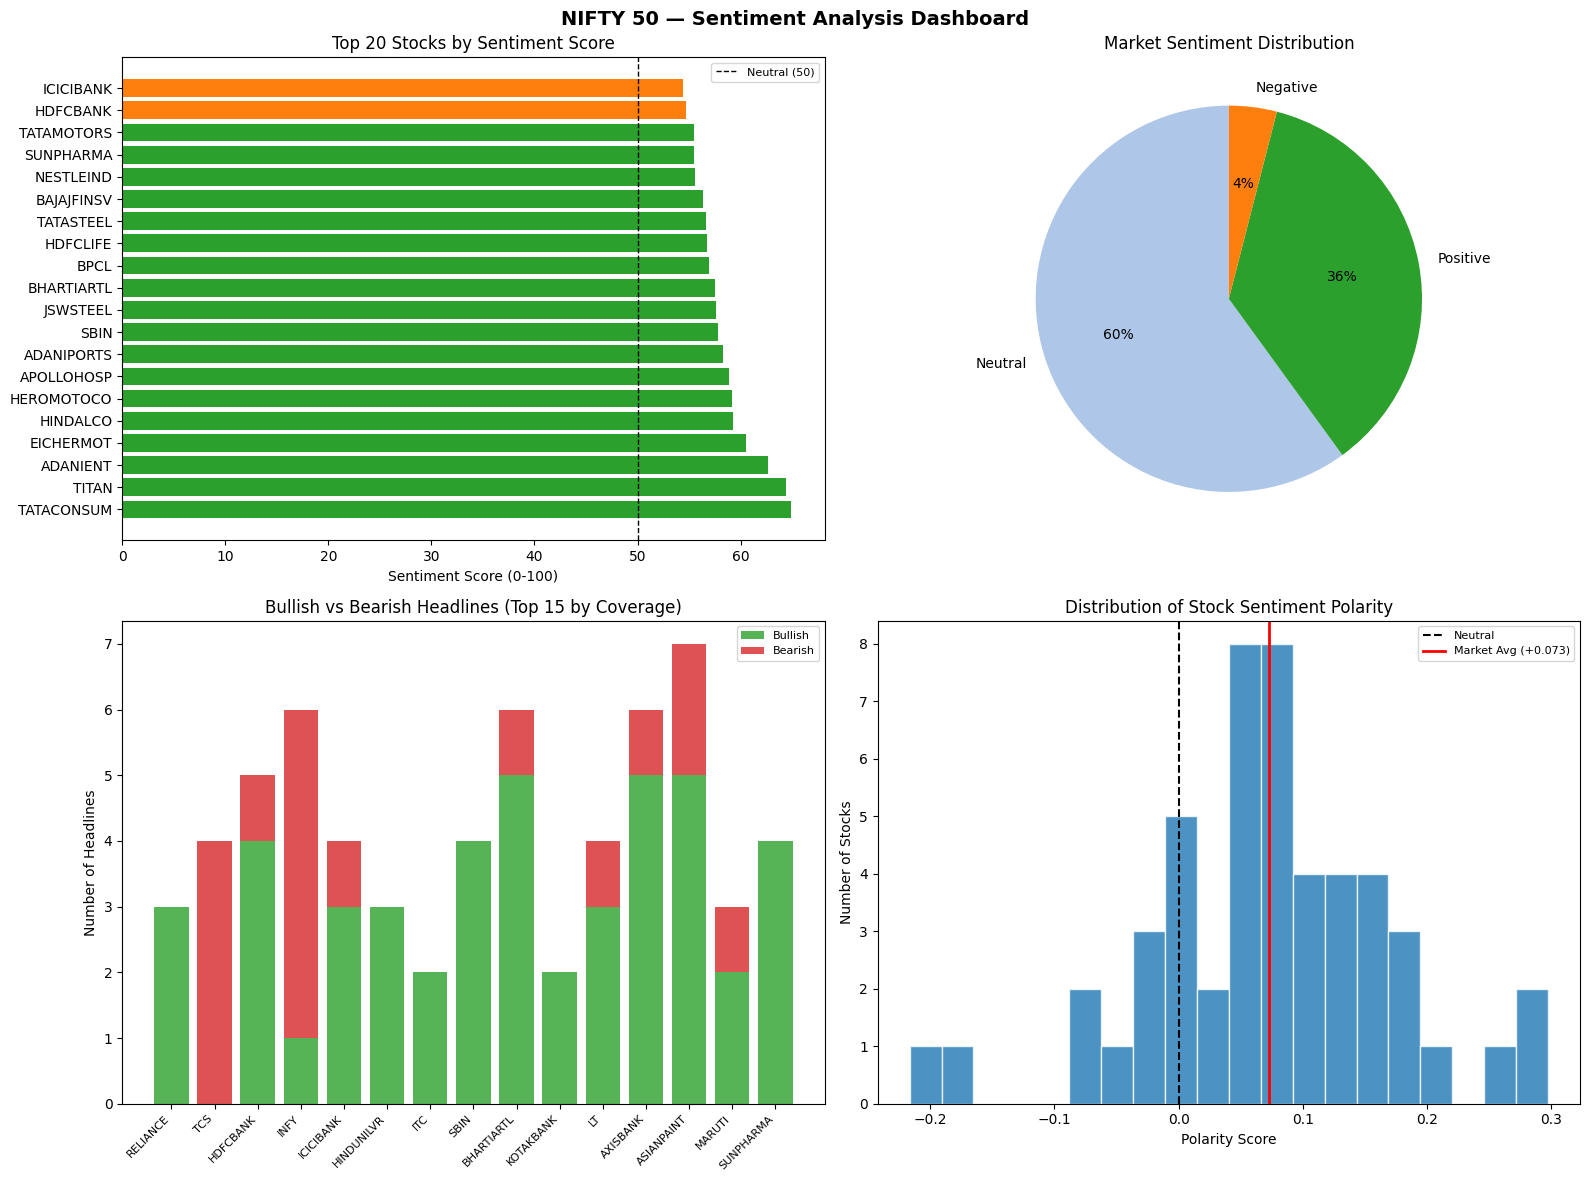

✅ Chart saved to Google Drive!


In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("NIFTY 50 — Sentiment Analysis Dashboard", fontsize=14, fontweight="bold")

# ── Plot 1: Sentiment Score by Stock (Top 20) ──
top20 = sentiment_df.nlargest(20, "Sentiment_Score")
colors = ["#2ca02c" if s > 55 else "#ff7f0e" if s > 45 else "#d62728"
          for s in top20["Sentiment_Score"]]
axes[0,0].barh(top20["Ticker"].str.replace(".NS",""),
               top20["Sentiment_Score"], color=colors)
axes[0,0].axvline(50, color="black", ls="--", lw=1, label="Neutral (50)")
axes[0,0].set_title("Top 20 Stocks by Sentiment Score")
axes[0,0].set_xlabel("Sentiment Score (0-100)")
axes[0,0].legend(fontsize=8)

# ── Plot 2: Sentiment Label Distribution ──
label_counts = sentiment_df["Sentiment_Label"].value_counts()
label_colors = {
    "Very Positive": "#1a7a1a", "Positive": "#2ca02c",
    "Neutral": "#aec7e8",
    "Negative": "#ff7f0e",     "Very Negative": "#d62728"
}
axes[0,1].pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[label_colors.get(l, "gray") for l in label_counts.index],
    autopct="%1.0f%%", startangle=90
)
axes[0,1].set_title("Market Sentiment Distribution")

# ── Plot 3: Bullish vs Bearish Headlines per Stock (Top 15) ──
top15 = sentiment_df.nlargest(15, "Total_Articles")
x = range(len(top15))
axes[1,0].bar(x, top15["Bullish_Count"],
              label="Bullish", color="#2ca02c", alpha=0.8)
axes[1,0].bar(x, top15["Bearish_Count"],
              bottom=top15["Bullish_Count"],
              label="Bearish", color="#d62728", alpha=0.8)
axes[1,0].set_xticks(list(x))
axes[1,0].set_xticklabels(
    top15["Ticker"].str.replace(".NS",""), rotation=45, ha="right", fontsize=8
)
axes[1,0].set_title("Bullish vs Bearish Headlines (Top 15 by Coverage)")
axes[1,0].set_ylabel("Number of Headlines")
axes[1,0].legend(fontsize=8)

# ── Plot 4: Polarity Distribution ──
axes[1,1].hist(sentiment_df["Avg_Polarity"], bins=20,
               color="#1f77b4", edgecolor="white", alpha=0.8)
axes[1,1].axvline(0,    color="black", ls="--", lw=1.5, label="Neutral")
axes[1,1].axvline(sentiment_df["Avg_Polarity"].mean(),
                  color="red", ls="-", lw=2,
                  label=f"Market Avg ({sentiment_df['Avg_Polarity'].mean():+.3f})")
axes[1,1].set_title("Distribution of Stock Sentiment Polarity")
axes[1,1].set_xlabel("Polarity Score")
axes[1,1].set_ylabel("Number of Stocks")
axes[1,1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{BASE}/data/output/04_sentiment_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved to Google Drive!")

In [10]:
def save_sentiment_data(sentiment_df, headlines_df):

    # Aggregated sentiment per stock
    sentiment_df.to_parquet(
        f"{BASE}/data/processed/nifty50_sentiment.parquet", index=False
    )
    sentiment_df.to_csv(
        f"{BASE}/data/output/nifty50_sentiment_powerbi.csv", index=False
    )
    print("✅ Sentiment scores saved")

    # All headlines (detailed)
    headlines_df.to_parquet(
        f"{BASE}/data/processed/nifty50_headlines.parquet", index=False
    )
    headlines_df.to_csv(
        f"{BASE}/data/output/nifty50_headlines_powerbi.csv", index=False
    )
    print("✅ Headlines data saved")

    # Combined summary
    print(f"\n📊 Files saved to Google Drive:")
    print(f"   → nifty50_sentiment_powerbi.csv     ({len(sentiment_df)} stocks)")
    print(f"   → nifty50_headlines_powerbi.csv     ({len(headlines_df)} headlines)")

save_sentiment_data(sentiment_df, headlines_df)

✅ Sentiment scores saved
✅ Headlines data saved

📊 Files saved to Google Drive:
   → nifty50_sentiment_powerbi.csv     (50 stocks)
   → nifty50_headlines_powerbi.csv     (500 headlines)


## ✅ Notebook 4 Complete!

**Save to GitHub:**
File → Save a copy in GitHub → `notebooks/04_sentiment_analysis.ipynb`
Commit message: `Add Notebook 4: Sentiment analysis using NLP on NIFTY 50 news headlines`

**Next:** Notebook 5 — Forecasting (Prophet + LSTM price prediction)